# Lecture 3: Central Limit Theorem & Confidence Intervals

**Topics:**
1. Normal distribution and population parameters
2. Drawing a single sample
3. Central Limit Theorem (CLT) — simulation
4. Standard Error of the mean
5. Confidence Intervals (known σ and unknown σ)


In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Population: Normal Distribution

A normal distribution is fully described by two parameters:

$$X \sim \mathcal{N}(\mu,\ \sigma^2)$$

| Parameter | Symbol | Role |
|-----------|--------|------|
| Mean | $\mu$ | Center (location) |
| Std deviation | $\sigma$ | Spread (scale) |

**Probability Density Function:**

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)$$

We simulate a population of $N = 10{,}000$ values with $\mu=100$, $\sigma=10$.


In [2]:
mu = 100
sigma = 10

In [3]:
population = np.random.normal(mu, sigma, 10_000).round(2)

In [4]:
print(f'Population size: {len(population)}')
print(f'Mean: {population.mean():.4f},  Std: {population.std():.4f}')

Population size: 10000
Mean: 99.9722,  Std: 9.9411


## 2. Drawing a Single Sample

A **random sample** of size $n$ is drawn without replacement from the population.  
The sample mean $\bar{x}$ is an **unbiased estimator** of $\mu$:

$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$


In [5]:
sample_size = 30

In [6]:
sample = np.random.choice(population, sample_size, replace=False)
print(f'Sample (n={sample_size}): {sample}')
print(f'Sample mean: {sample.mean():.4f}')

Sample (n=30): [100.06 102.49  92.12  91.3   87.69 103.36 113.21 101.8  100.28 107.84
 121.19 107.96 111.99 104.11 100.57 107.54  99.05  95.24  99.24 100.12
  87.12  93.23 118.86  96.16  89.79  92.17  84.65 103.84  88.9   96.54]
Sample mean: 99.9473


## 3. Central Limit Theorem (CLT)

> **CLT:** The distribution of sample means $\bar{X}$ approaches a normal distribution as $n \to \infty$,  
> regardless of the shape of the population distribution (rule of thumb: $n \geq 30$).

$$\bar{X} \sim \mathcal{N}\!\left(\mu,\ \frac{\sigma^2}{n}\right)$$

**Empirical rule (3-sigma rule):**

| Range | Coverage |
|-------|---------|
| $\mu \pm 1\sigma$ | ≈ 68% |
| $\mu \pm 1.96\sigma$ | ≈ 95% |
| $\mu \pm 3\sigma$ | ≈ 99.7% |

Below: draw $10{,}000$ samples of size $n=30$ and plot the distribution of their means.


In [7]:
n_simulations = 10_000
sample_means = []
for _ in range(n_simulations):
    s = np.random.choice(population, sample_size, replace=False)
    sample_means.append(s.mean())

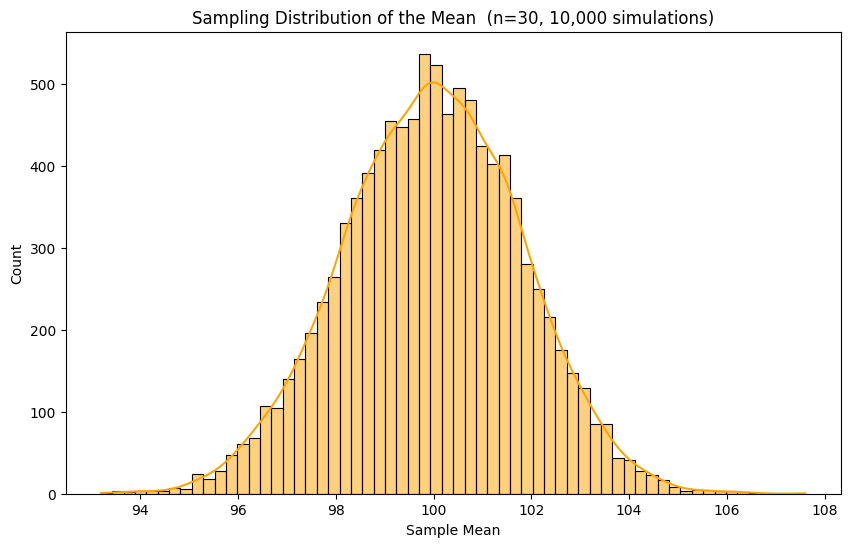

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(sample_means, kde=True, color='orange')
plt.title(f'Sampling Distribution of the Mean  (n={sample_size}, {n_simulations:,} simulations)')
plt.xlabel('Sample Mean')
plt.ylabel('Count')
plt.show()

In [9]:
print(f'Mean of sample means : {np.mean(sample_means):.4f}')
print(f'Population mean (μ)  : {population.mean():.4f}')

Mean of sample means : 99.9703
Population mean (μ)  : 99.9722


## 4. Standard Error (SE)

The **Standard Error** is the standard deviation of the sampling distribution of the mean:

$$SE = \frac{\sigma}{\sqrt{n}}$$

- Larger $n$ → smaller $SE$ → more precise estimates  
- `np.std(sample_means)` ≈ theoretical $SE$ — empirical confirmation of CLT


In [10]:
se = population.std() / sample_size**0.5
print(f'Theoretical SE = σ/√n : {se:.4f}')
print(f'Empirical SE (sim)    : {np.std(sample_means):.4f}')

Theoretical SE = σ/√n : 1.8150
Empirical SE (sim)    : 1.8180


## 5. Confidence Intervals (CI)

A **confidence interval** gives a range of plausible values for the population mean:

$$CI = \bar{x} \pm z^* \cdot SE$$

| Confidence Level | $z^*$ |
|-----------------|-------|
| 90% | 1.645 |
| **95%** | **1.960** |
| 99% | 2.576 |

> **Interpretation:** If we repeated sampling many times, ~95% of constructed intervals  
> would contain the true $\mu$ — not that a single interval has 95% probability.

---

### Case A — Known population $\sigma$ (theoretical)

$$CI = \mu_{sample} \pm 1.96 \cdot \frac{\sigma}{\sqrt{n}}$$

### Case B — Unknown $\sigma$ (real-world, $n \geq 30$)

Estimate $\sigma$ with the **sample standard deviation** $s$ (Bessel's correction, `ddof=1`):

$$\hat{SE} = \frac{s}{\sqrt{n}}, \qquad CI = \bar{x} \pm 1.96 \cdot \hat{SE}$$

> For $n < 30$, replace $z^* = 1.96$ with the $t$-critical value (`scipy.stats.t.ppf(0.975, df=n-1)`).


In [11]:
# Case A: known σ — CI around the (known) population mean
lower_a = population.mean() - 1.96 * se
upper_a = population.mean() + 1.96 * se
print(f'95% CI (known σ): [{lower_a:.2f}, {upper_a:.2f}]')

95% CI (known σ): [96.41, 103.53]


In [12]:
# Case B: one real sample, σ unknown — estimate SE from sample std
sample_real = np.random.choice(population, sample_size, replace=False)
x_bar  = sample_real.mean()
se_hat = sample_real.std(ddof=1) / sample_size**0.5  # unbiased Bessel-corrected std

lower_b = x_bar - 1.96 * se_hat
upper_b = x_bar + 1.96 * se_hat

print(f'Sample mean (x̄)      : {x_bar:.4f}')
print(f'Estimated SE (s/√n)  : {se_hat:.4f}')
print(f'95% CI (estimated σ) : [{lower_b:.2f}, {upper_b:.2f}]')
print(f'True μ={mu} inside CI : {lower_b <= mu <= upper_b}')

Sample mean (x̄)      : 100.2663
Estimated SE (s/√n)  : 1.8789
95% CI (estimated σ) : [96.58, 103.95]
True μ=100 inside CI : True
